In [65]:
import pandas as pd
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

In [66]:
df = pd.read_csv('Encrypted_Data.csv')
df.head()

,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,932760,251918,765769,193896,938325,539163,505110,367137,178233,929086,566939,0
1,296821,836581,872650,902128,253691,539163,505110,612315,178233,908449,673385,1
2,468699,251918,765769,790577,76424,539163,642628,383666,178233,929086,566939,0
3,505866,836581,173890,819212,667549,539163,505110,464210,346581,363393,673385,1
4,386166,251918,872650,239440,423407,539163,505110,344099,178233,929086,566939,0


In [67]:
X = df.drop(['HeartDisease'], axis='columns')
X

,Age,Sex,ChestPainType,RestingBloodPressure,Cholesterol,FastingBloodSugar,RestingECG,MaximumHeartRate,ExerciseAngina,Oldpeak,ST_Slope
0,932760,251918,765769,193896,938325,539163,505110,367137,178233,929086,566939
1,296821,836581,872650,902128,253691,539163,505110,612315,178233,908449,673385
2,468699,251918,765769,790577,76424,539163,642628,383666,178233,929086,566939
3,505866,836581,173890,819212,667549,539163,505110,464210,346581,363393,673385
4,386166,251918,872650,239440,423407,539163,505110,344099,178233,929086,566939
...,...,...,...,...,...,...,...,...,...,...,...
3245,586032,836581,872650,501901,195452,539163,505110,322940,178233,363393,673385
3246,918576,836581,872650,720221,571025,539163,642628,915217,178233,716435,673385
3247,682389,251918,768809,414814,681648,539163,642628,336369,346581,929086,263693
3248,768736,251918,173890,902128,235877,539163,505110,132558,178233,929086,263693


In [68]:
Y = df[['HeartDisease']]
Y

,HeartDisease
0,0
1,1
2,0
3,1
4,0
...,...
3245,1
3246,1
3247,0
3248,0


In [69]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [70]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

In [71]:
Y_train = Y_train.replace({2679: 1, 167469: 0})
Y_test = Y_test.replace({2679: 1, 167469: 0})

Confusion Matrix   : [[254 158]
 [137 426]]
Accuracy   : 0.6974358974358974
Precision : 0.7294520547945206
Recall    : 0.7566607460035524
F1-score  : 0.7428073234524848
AUC: 0.6865828001862422
Confusion Matrix:
[[254 158]
 [137 426]]
Sensitivity (True Positive Rate): 0.7566607460035524
Specificity (True Negative Rate): 0.616504854368932
Precision: 0.7294520547945206
False Omission Rate: 0.535593220338983
Diagnostic Odds Ratio: 1.934249094775562


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


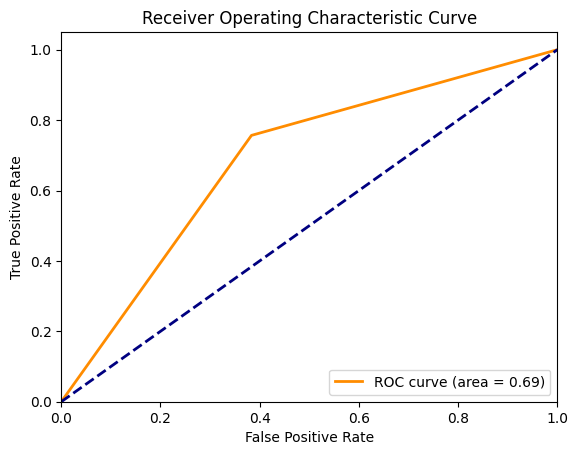

In [72]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
model_lr = lr.fit(X_train, Y_train)

pred_lr = model_lr.predict(X_test)

cm_lr = confusion_matrix(Y_test, pred_lr)
print("Confusion Matrix   :", cm_lr)

accuracy_lr = accuracy_score(Y_test, pred_lr)
print("Accuracy   :", accuracy_lr)

precision_lr = precision_score(Y_test, pred_lr)
print("Precision :", precision_lr)

recall_lr = recall_score(Y_test, pred_lr)
print("Recall    :", recall_lr)

F1_score_lr = f1_score(Y_test, pred_lr)
print("F1-score  :", F1_score_lr)

auc_lr = roc_auc_score(Y_test, pred_lr)
print("AUC:", auc_lr)

conf_matrix_lr = confusion_matrix(Y_test, pred_lr)
print("Confusion Matrix:")
print(conf_matrix_lr)

sensitivity_lr = conf_matrix_lr[1, 1] / (conf_matrix_lr[1, 1] + conf_matrix_lr[1, 0])
print("Sensitivity (True Positive Rate):", sensitivity_lr)

specificity_lr = conf_matrix_lr[0, 0] / (conf_matrix_lr[0, 0] + conf_matrix_lr[0, 1])
print("Specificity (True Negative Rate):", specificity_lr)

precision = conf_matrix_lr[1, 1] / (conf_matrix_lr[1, 1] + conf_matrix_lr[0, 1])
print("Precision:", precision_lr)

false_omission_rate_lr = conf_matrix_lr[0, 1] / (conf_matrix_lr[0, 1] + conf_matrix_lr[1, 0])
print("False Omission Rate:", false_omission_rate_lr)

dor_lr = (sensitivity_lr / (1 - sensitivity_lr)) / (specificity_lr / (1 - specificity_lr))
print("Diagnostic Odds Ratio:", dor_lr)

fpr_lr, tpr_lr, _ = roc_curve(Y_test, pred_lr)
plt.figure()
plt.plot(fpr_lr, tpr_lr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_lr)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

Confusion Matrix:
[[352  60]
 [107 456]]
Accuracy: 0.8287179487179487
Precision: 0.8837209302325582
Recall: 0.8099467140319716
F1-score: 0.845227062094532
AUC Score: 0.8321578230354033
Specificity (True Negative Rate): 0.8543689320388349


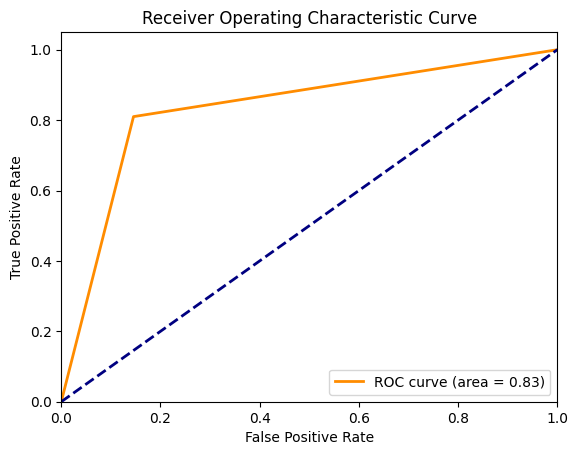

In [73]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()

model_dtc = dtc.fit(X_train, Y_train)

pred_dtc = model_dtc.predict(X_test)

cm_dtc = confusion_matrix(Y_test, pred_dtc)
print("Confusion Matrix:")
print(cm_dtc)

accuracy_dtc = accuracy_score(Y_test, pred_dtc)
print("Accuracy:", accuracy_dtc)

precision_dtc = precision_score(Y_test, pred_dtc)
print("Precision:", precision_dtc)

recall_dtc = recall_score(Y_test, pred_dtc)
print("Recall:", recall_dtc)

f1_score_dtc = f1_score(Y_test, pred_dtc)
print("F1-score:", f1_score_dtc)

auc_dtc = roc_auc_score(Y_test, pred_dtc)
print("AUC Score:", auc_dtc)

specificity_dtc = cm_dtc[0, 0] / (cm_dtc[0, 0] + cm_dtc[0, 1])
print("Specificity (True Negative Rate):", specificity_dtc)

fpr_dtc, tpr_dtc, _ = roc_curve(Y_test, pred_dtc)
plt.figure()
plt.plot(fpr_dtc, tpr_dtc, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_dtc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[305 107]
 [108 455]]
Accuracy: 0.7794871794871795
Precision: 0.8096085409252669
Recall: 0.8081705150976909
F1-score: 0.8088888888888889
AUC Score: 0.7742308886168066
Specificity (True Negative Rate): 0.7402912621359223


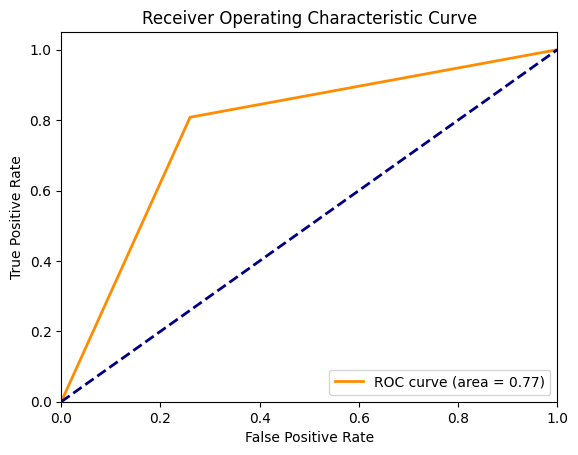

In [74]:
from sklearn.svm import SVC

svc = SVC()

model_svc = svc.fit(X_train, Y_train)

pred_svc = model_svc.predict(X_test)

cm_svc = confusion_matrix(Y_test, pred_svc)
print("Confusion Matrix:")
print(cm_svc)

accuracy_svc = accuracy_score(Y_test, pred_svc)
print("Accuracy:", accuracy_svc)

precision_svc = precision_score(Y_test, pred_svc)
print("Precision:", precision_svc)

recall_svc = recall_score(Y_test, pred_svc)
print("Recall:", recall_svc)

f1_score_svc = f1_score(Y_test, pred_svc)
print("F1-score:", f1_score_svc)

auc_svc = roc_auc_score(Y_test, pred_svc)
print("AUC Score:", auc_svc)

specificity_svc = cm_svc[0, 0] / (cm_svc[0, 0] + cm_svc[0, 1])
print("Specificity (True Negative Rate):", specificity_svc)

fpr_svc, tpr_svc, _ = roc_curve(Y_test, pred_svc)
plt.figure()
plt.plot(fpr_svc, tpr_svc, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_svc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

Confusion Matrix:
[[268 144]
 [117 446]]
Accuracy: 0.7323076923076923
Precision: 0.7559322033898305
Recall: 0.7921847246891652
F1-score: 0.7736339982653946
AUC Score: 0.7213350807911845
Specificity (True Negative Rate): 0.6504854368932039


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


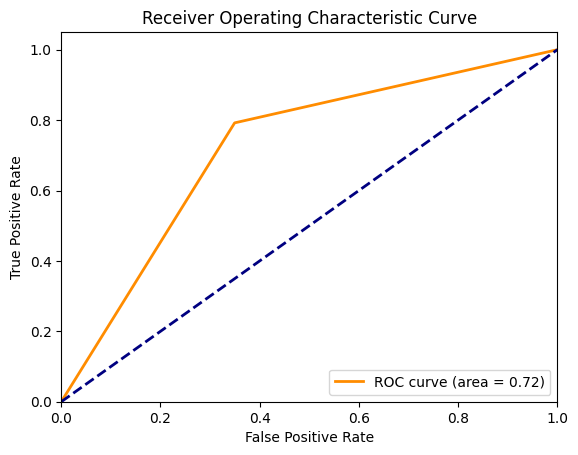

In [75]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

model_gnb = gnb.fit(X_train, Y_train)

pred_gnb = model_gnb.predict(X_test)

cm_gnb = confusion_matrix(Y_test, pred_gnb)
print("Confusion Matrix:")
print(cm_gnb)

accuracy_gnb = accuracy_score(Y_test, pred_gnb)
print("Accuracy:", accuracy_gnb)

precision_gnb = precision_score(Y_test, pred_gnb)
print("Precision:", precision_gnb)

recall_gnb = recall_score(Y_test, pred_gnb)
print("Recall:", recall_gnb)

f1_score_gnb = f1_score(Y_test, pred_gnb)
print("F1-score:", f1_score_gnb)

auc_gnb = roc_auc_score(Y_test, pred_gnb)
print("AUC Score:", auc_gnb)

specificity_gnb = cm_gnb[0, 0] / (cm_gnb[0, 0] + cm_gnb[0, 1])
print("Specificity (True Negative Rate):", specificity_gnb)

fpr_gnb, tpr_gnb, _ = roc_curve(Y_test, pred_gnb)
plt.figure()
plt.plot(fpr_gnb, tpr_gnb, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_gnb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neighbors\_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


Confusion Matrix:
[[287 125]
 [171 392]]
Accuracy: 0.6964102564102564
Precision: 0.758220502901354
Recall: 0.6962699822380106
F1-score: 0.725925925925926
AUC Score: 0.6964359619927917
Specificity (True Negative Rate): 0.6966019417475728


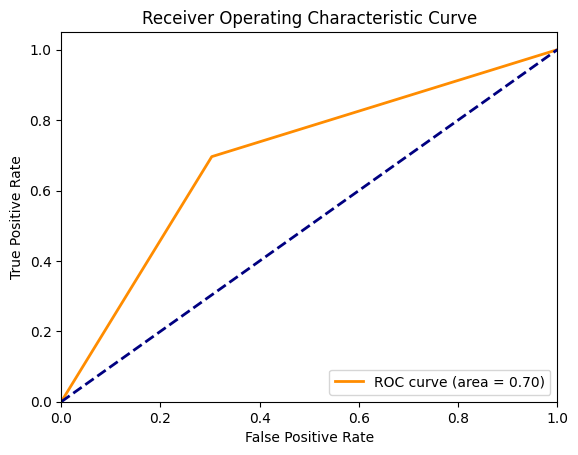

In [76]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

model_knn = knn.fit(X_train, Y_train)

pred_knn = model_knn.predict(X_test)

cm_knn = confusion_matrix(Y_test, pred_knn)
print("Confusion Matrix:")
print(cm_knn)

accuracy_knn = accuracy_score(Y_test, pred_knn)
print("Accuracy:", accuracy_knn)

precision_knn = precision_score(Y_test, pred_knn)
print("Precision:", precision_knn)

recall_knn = recall_score(Y_test, pred_knn)
print("Recall:", recall_knn)

f1_score_knn = f1_score(Y_test, pred_knn)
print("F1-score:", f1_score_knn)

auc_knn = roc_auc_score(Y_test, pred_knn)
print("AUC Score:", auc_knn)

specificity_knn = cm_knn[0, 0] / (cm_knn[0, 0] + cm_knn[0, 1])
print("Specificity (True Negative Rate):", specificity_knn)

fpr_knn, tpr_knn, _ = roc_curve(Y_test, pred_knn)
plt.figure()
plt.plot(fpr_knn, tpr_knn, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_knn)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

Confusion Matrix:
[[183 229]
 [197 366]]
Accuracy: 0.563076923076923
Precision: 0.6151260504201681
Recall: 0.650088809946714
F1-score: 0.6321243523316062
AUC Score: 0.5471317836141337
Specificity (True Negative Rate): 0.4441747572815534


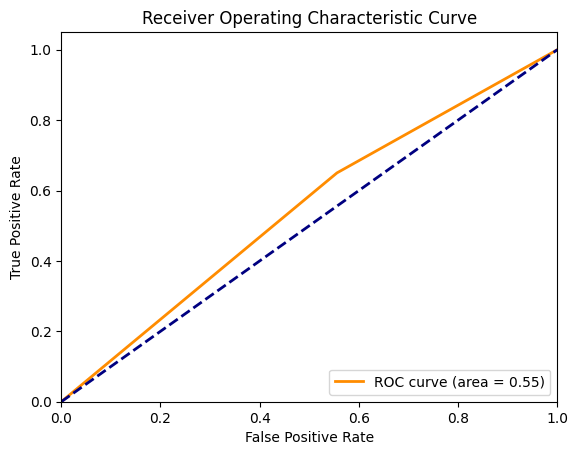

In [77]:
from xgboost import XGBClassifier

xgb = XGBClassifier()

model_xgb = xgb.fit(X_train, Y_train)

pred_xgb = model_xgb.predict(X_test)

cm_xgb = confusion_matrix(Y_test, pred_xgb)
print("Confusion Matrix:")
print(cm_xgb)

accuracy_xgb = accuracy_score(Y_test, pred_xgb)
print("Accuracy:", accuracy_xgb)

precision_xgb = precision_score(Y_test, pred_xgb)
print("Precision:", precision_xgb)

recall_xgb = recall_score(Y_test, pred_xgb)
print("Recall:", recall_xgb)

f1_score_xgb = f1_score(Y_test, pred_xgb)
print("F1-score:", f1_score_xgb)

auc_xgb = roc_auc_score(Y_test, pred_xgb)
print("AUC Score:", auc_xgb)

specificity_xgb = cm_xgb[0, 0] / (cm_xgb[0, 0] + cm_xgb[0, 1])
print("Specificity (True Negative Rate):", specificity_xgb)

fpr_xgb, tpr_xgb, _ = roc_curve(Y_test, pred_xgb)
plt.figure()
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_xgb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1474: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Confusion Matrix:
[[387  25]
 [ 48 515]]
Accuracy: 0.9251282051282051
Precision: 0.9537037037037037
Recall: 0.9147424511545293
F1-score: 0.9338168631006346
AUC Score: 0.927031419752022
Specificity (True Negative Rate): 0.9393203883495146


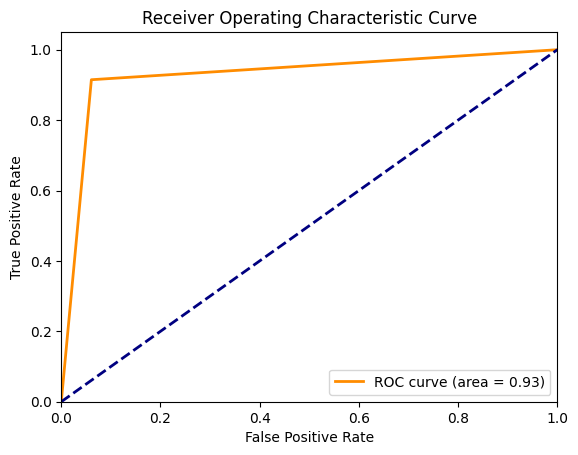

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

model_rf = rf.fit(X_train, Y_train)

pred_rf = model_rf.predict(X_test)

cm_rf = confusion_matrix(Y_test, pred_rf)
print("Confusion Matrix:")
print(cm_rf)

accuracy_rf = accuracy_score(Y_test, pred_rf)
print("Accuracy:", accuracy_rf)

precision_rf = precision_score(Y_test, pred_rf)
print("Precision:", precision_rf)

recall_rf = recall_score(Y_test, pred_rf)
print("Recall:", recall_rf)

f1_score_rf = f1_score(Y_test, pred_rf)
print("F1-score:", f1_score_rf)

auc_rf = roc_auc_score(Y_test, pred_rf)
print("AUC Score:", auc_rf)

specificity_rf = cm_rf[0, 0] / (cm_rf[0, 0] + cm_rf[0, 1])
print("Specificity (True Negative Rate):", specificity_rf)

fpr_rf, tpr_rf, _ = roc_curve(Y_test, pred_rf)
plt.figure()
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_rf)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Confusion Matrix:
[[301 111]
 [143 420]]
Accuracy: 0.7394871794871795
Precision: 0.7909604519774012
Recall: 0.7460035523978685
F1-score: 0.7678244972577697
AUC Score: 0.7382930383348566
Specificity (True Negative Rate): 0.7305825242718447


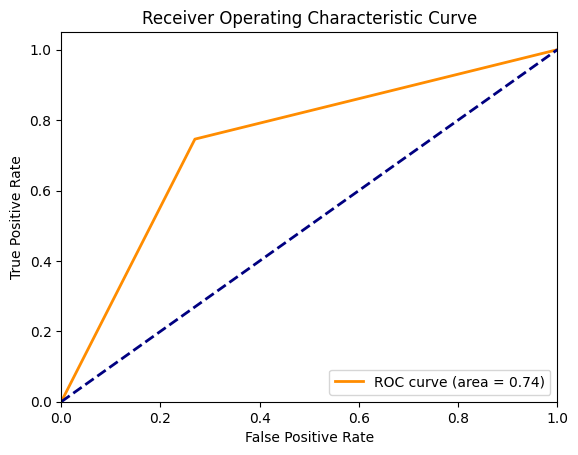

In [79]:
from sklearn.ensemble import AdaBoostClassifier

adb = AdaBoostClassifier()

model_adb = adb.fit(X_train, Y_train)

pred_adb = model_adb.predict(X_test)

cm_adb = confusion_matrix(Y_test, pred_adb)
print("Confusion Matrix:")
print(cm_adb)

accuracy_adb = accuracy_score(Y_test, pred_adb)
print("Accuracy:", accuracy_adb)

precision_adb = precision_score(Y_test, pred_adb)
print("Precision:", precision_adb)

recall_adb = recall_score(Y_test, pred_adb)
print("Recall:", recall_adb)

f1_score_adb = f1_score(Y_test, pred_adb)
print("F1-score:", f1_score_adb)

auc_adb = roc_auc_score(Y_test, pred_adb)
print("AUC Score:", auc_adb)

specificity_adb = cm_adb[0, 0] / (cm_adb[0, 0] + cm_adb[0, 1])
print("Specificity (True Negative Rate):", specificity_adb)

fpr_adb, tpr_adb, _ = roc_curve(Y_test, pred_adb)
plt.figure()
plt.plot(fpr_adb, tpr_adb, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_adb)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1101: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Confusion Matrix:
[[317  95]
 [ 92 471]]
Accuracy: 0.8082051282051282
Precision: 0.8321554770318021
Recall: 0.8365896980461812
F1-score: 0.8343666961913198
AUC Score: 0.8030035868871683


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


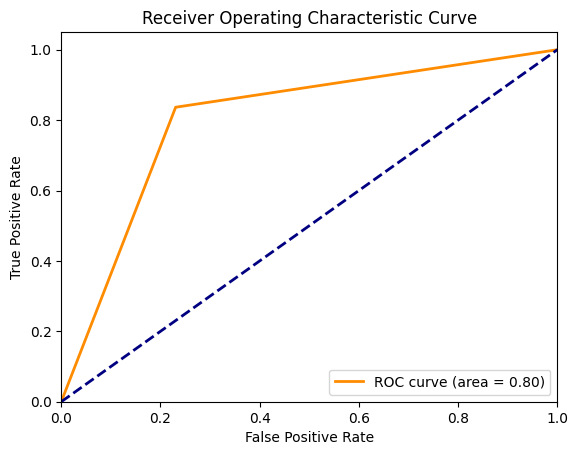

In [80]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier()

model_mlp = mlp.fit(X_train, Y_train)

pred_mlp = model_mlp.predict(X_test)

cm_mlp = confusion_matrix(Y_test, pred_mlp)
print("Confusion Matrix:")
print(cm_mlp)

accuracy_mlp = accuracy_score(Y_test, pred_mlp)
print("Accuracy:", accuracy_mlp)

precision_mlp = precision_score(Y_test, pred_mlp)
print("Precision:", precision_mlp)

recall_mlp = recall_score(Y_test, pred_mlp)
print("Recall:", recall_mlp)

f1_score_mlp = f1_score(Y_test, pred_mlp)
print("F1-score:", f1_score_mlp)

auc_mlp = roc_auc_score(Y_test, pred_mlp)
print("AUC Score:", auc_mlp)

fpr_mlp, tpr_mlp, _ = roc_curve(Y_test, pred_mlp)
plt.figure()
plt.plot(fpr_mlp, tpr_mlp, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % auc_mlp)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic Curve')
plt.legend(loc="lower right")
plt.show()